In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

In [2]:
import pandas as pd

# Load files
lcadeci = pd.read_csv("lcadeci_subs_2026-04-08.csv")
query = pd.read_csv("query_result_2026-04-09T01_20_25.459920945Z.csv")

# Deduplicate query_result: keep row with shortest owner_address per user_id
query["owner_address_len"] = query["owner_address"].fillna("").str.len()
query_dedup = (
    query.sort_values("owner_address_len")
         .drop_duplicates(subset="user_id", keep="first")
         .drop(columns="owner_address_len")
)

# Join: query_result.user_id = lcadeci.owner
result = query_dedup.merge(lcadeci, left_on="user_id", right_on="owner", how="inner")

print(f"query rows: {len(query)} → deduplicated: {len(query_dedup)}")
print(f"lcadeci rows: {len(lcadeci)}")
print(f"joined rows: {len(result)}")
result
result.to_csv("eoa_lcadeci.csv", index=False)

query rows: 95 → deduplicated: 54
lcadeci rows: 61
joined rows: 58


In [4]:
lcadeci_unique = lcadeci.drop_duplicates(subset="owner")
lcadeci_unique.to_csv("lcadeci_unique.csv", index=False)

In [1]:
def extract_bscan(T_volume, y_index):
    """
    Extracts a B-scan from a complex 3D OCT volume and returns the log-intensity.
    T_volume: 3D numpy array of complex numbers T(z, x, y)
    y_index: Integer index for the slice
    """
    # Slice the volume along the y-axis to get a B-scan: T(z, x)
    bscan_complex = T_volume[:, :, y_index]
    
    # Extract amplitude and convert to dB scale for standard OCT viewing
    # Adding a small epsilon to avoid log(0)
    amplitude = np.abs(bscan_complex)
    bscan_db = 20 * np.log10(amplitude + 1e-12)
    
    return bscan_complex, bscan_db

In [ ]:
def get_expanded_kernels():
    """Returns an expanded dictionary of 2D convolution kernels categorized by function."""
    kernels = {}
    
    # ==========================================
    # 1. SMOOTHING & NOISE REDUCTION
    # (Crucial for mitigating OCT speckle before edge detection)
    # ==========================================
    
    # Box Blur: Simple local average. Fast, but can over-blur boundaries.
    kernels['Box_Blur_3x3'] = (1 / 9.0) * np.ones((3, 3))
    
    # 5x5 Gaussian: Stronger speckle mitigation while preserving lower-frequency layer structures better than a box blur.
    flat_gaussian = [
        1, 4, 6, 4, 1,
        4, 16, 24, 16, 4,
        6, 24, 36, 24, 6,
        4, 16, 24, 16, 4,
        1, 4, 6, 4, 1
    ]

    kernels['Gaussian_5x5'] = (1 / 256.0) * np.array(flat_gaussian).reshape(5, 5)

    # ==========================================
    # 2. FIRST-ORDER EDGE DETECTION (GRADIENTS)
    # (Used for finding macroscopic tissue layers and boundaries)
    # ==========================================
    
    # Prewitt: Similar to Sobel, but does not place extra weight on the center pixel. 
    # Can be slightly less sensitive to high-frequency speckle when finding horizontal layers.
    kernels['Prewitt_Z'] = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ])
    kernels['Prewitt_X'] = np.array([
        [-1,  0,  1],
        [-1,  0,  1],
        [-1,  0,  1]
    ])

    # Scharr: Offers better rotational symmetry than Sobel. 
    # Excellent for capturing subtle, angled tissue gradients rather than strictly horizontal/vertical ones.
    kernels['Scharr_Z'] = np.array([
        [-3, -10, -3],
        [ 0,   0,  0],
        [ 3,  10,  3]
    ])
    kernels['Scharr_X'] = np.array([
        [-3,  0,  3],
        [-10, 0, 10],
        [-3,  0,  3]
    ])

    # Roberts Cross: A 2x2 kernel that highlights high-frequency diagonal edges. 
    # Useful for finding small, angled structures (e.g., micro-vessels or structural anomalies).
    kernels['Roberts_Pos'] = np.array([
        [ 1,  0],
        [ 0, -1]
    ])
    kernels['Roberts_Neg'] = np.array([
        [ 0,  1],
        [-1,  0]
    ])

    # ==========================================
    # 3. SECOND-ORDER & FEATURE EXTRACTION
    # ==========================================
    
    # Laplacian of Gaussian (LoG): Applies a Gaussian blur and a Laplacian in one pass.
    # Highly effective for OCT because it suppresses speckle first, then finds zero-crossings (edges).
    kernels['LoG_5x5'] = np.array([
        [ 0,  0, -1,  0,  0],
        [ 0, -1, -2, -1,  0],
        [-1, -2, 16, -2, -1],
        [ 0, -1, -2, -1,  0],
        [ 0,  0, -1,  0,  0]
    ])
    
    # Unsharp Masking: Subtracts a blurred version from the original. 
    # Enhances high-frequency details, making distinct boundaries (like the ILM or RPE in retinal OCT) "pop".
    kernels['Unsharp_Mask'] = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])
    
    # Emboss: Replaces each pixel with a shadow/highlight based on the gradient.
    # Creates a pseudo-3D topological map, which can visually assist in inspecting surface morphology.
    kernels['Emboss'] = np.array([
        [-2, -1,  0],
      [-1,  1,  1],
        [ 0,  1,  2]
    ])  

    return kernels

In [4]:
def apply_kernels(image, kernels):
    """
    Applies a dictionary of kernels to a 2D image.
    Returns a dictionary of processed images.
    """
    results = {}
    for name, kernel in kernels.items():
        # mode='same' keeps the output size identical to the input
        # boundary='symm' helps prevent harsh edge artifacts
        convolved = convolve2d(image, kernel, mode='same', boundary='symm')
        results[name] = convolved
        
    return results

In [5]:
def visualize_results(original_image, processed_images, cmap='gray'):
    """Plots the original image and the convolution results."""
    num_plots = len(processed_images) + 1
    cols = 3
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    # Plot Original
    axes[0].imshow(original_image, cmap=cmap)
    axes[0].set_title("Original (Log-Intensity)")
    axes[0].axis('off')
    
    # Plot Convolutions
    for i, (name, img) in enumerate(processed_images.items()):
        ax = axes[i + 1]
        
        # For gradient kernels like Sobel/Laplacian, a divergent colormap or absolute value can be better
        if 'Sobel' in name or 'Laplacian' in name:
            vmax = np.max(np.abs(img))
            ax.imshow(img, cmap='RdBu', vmin=-vmax, vmax=vmax)
        else:
            ax.imshow(img, cmap=cmap)
            
        ax.set_title(f"Filter: {name}")
        ax.axis('off')
        
    # Hide any unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

Successfully loaded volume.
Extracted B-scan at Y-index 25. Shape: (512, 512)


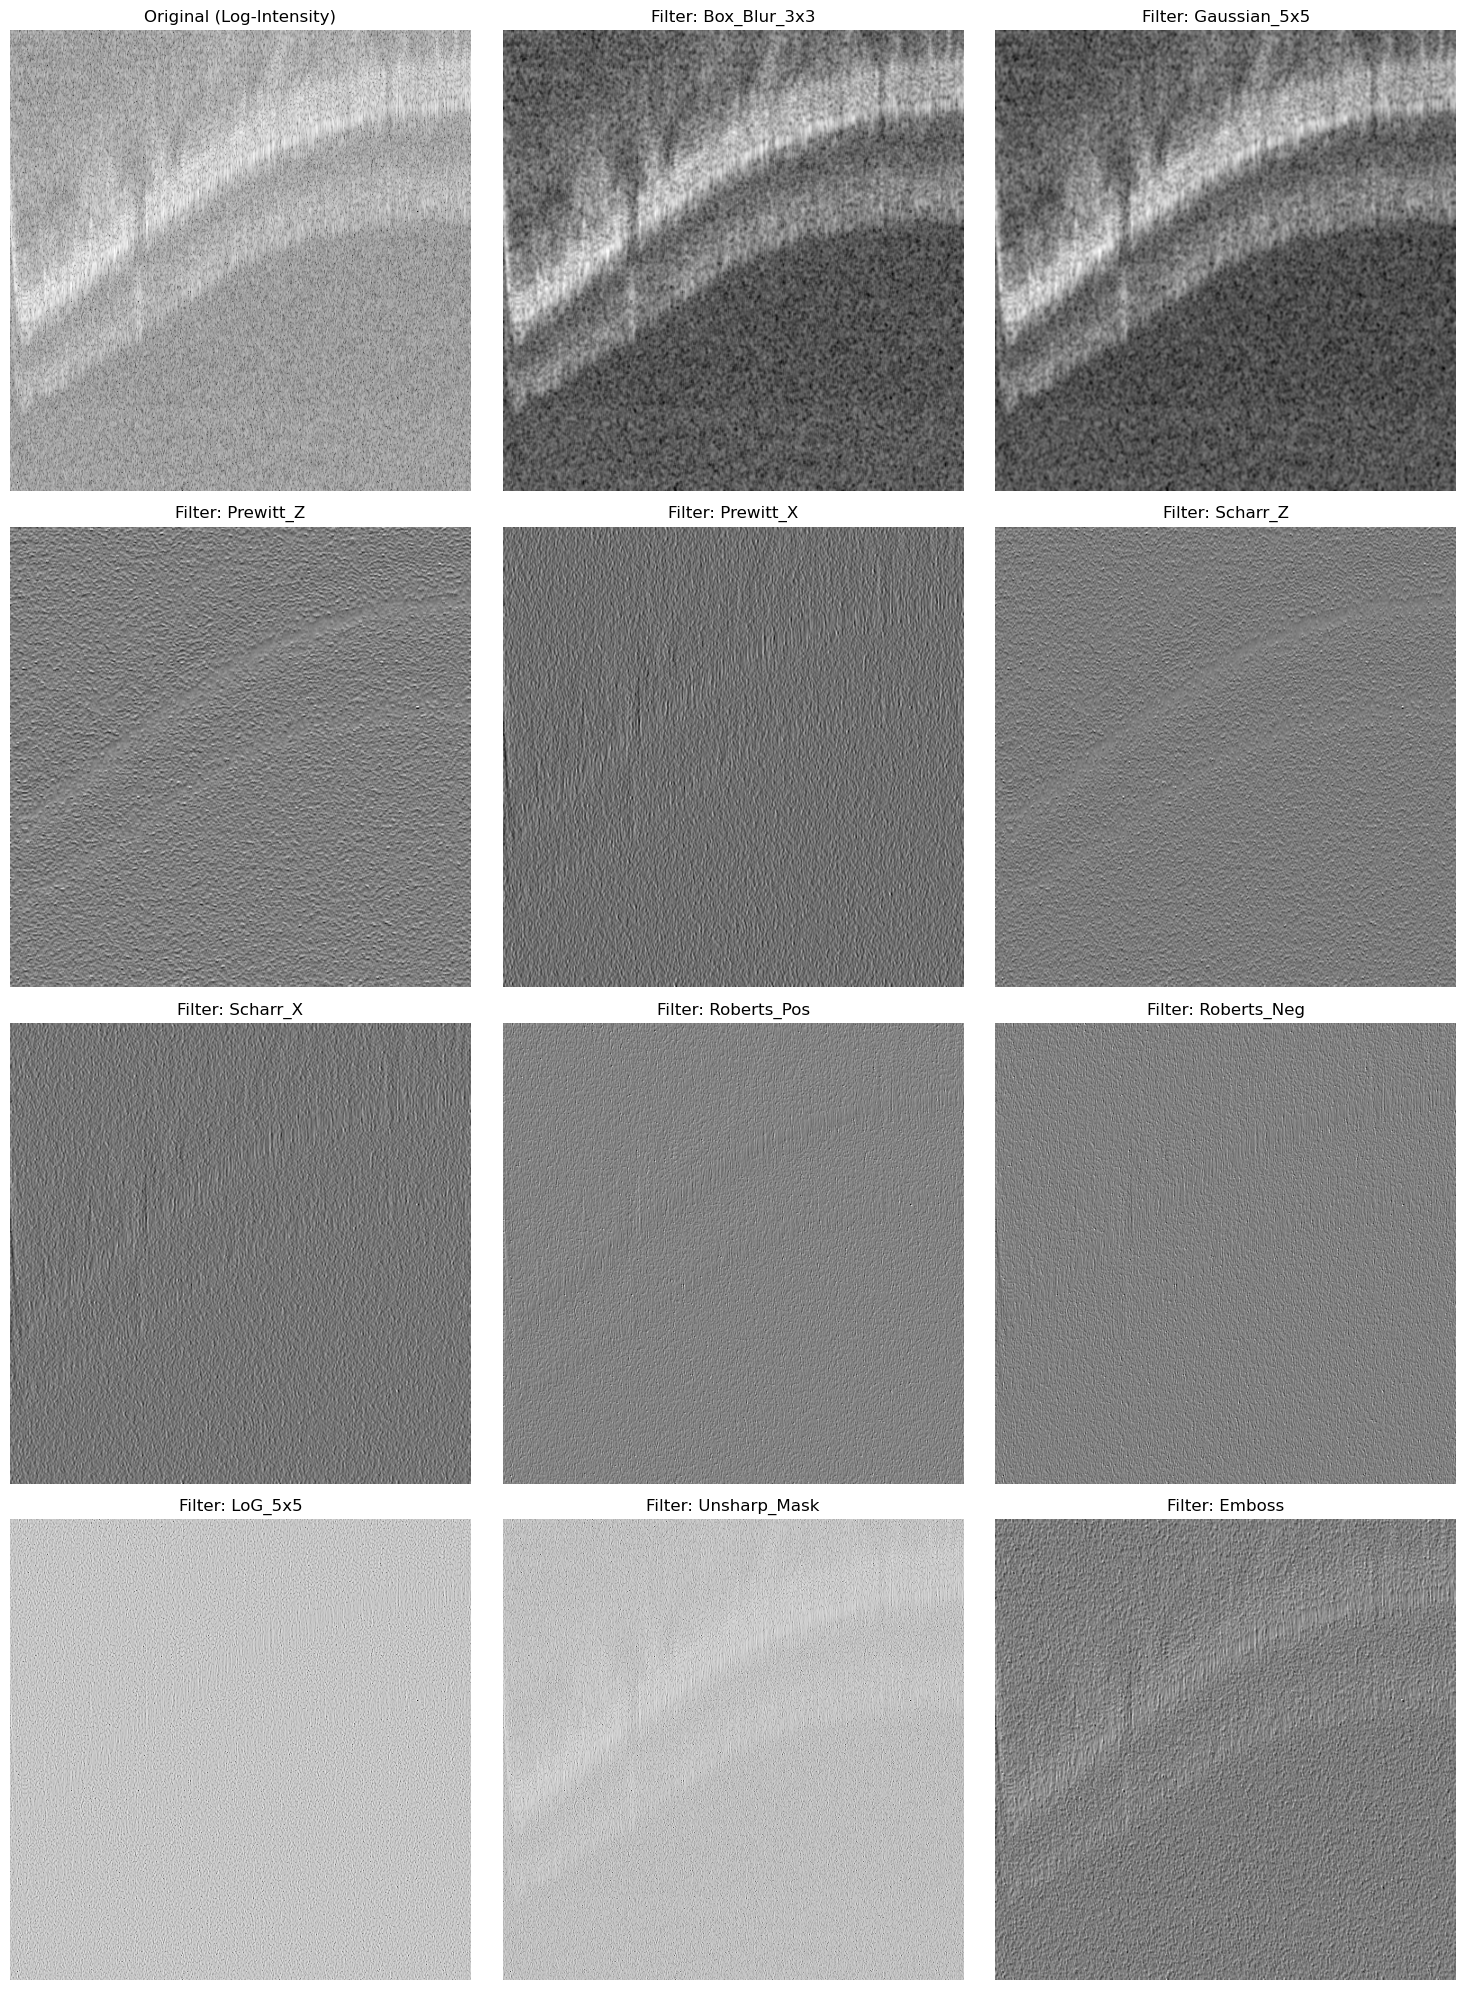

In [7]:
import numpy as np

# ==========================================
# 1. LOAD YOUR TOMOGRAM HERE
# ==========================================
# Paste the directory path or link to your processed complex volume file.
# Example: 'C:/data/oct_volume_processed.npy' 
# If you are using Google Colab, it might look like '/content/drive/MyDrive/oct_volume.npy'
TOMOGRAM_PATH = r"C:\Users\jcosp\dev\dloct-thesis\data\train\phase\Fovea1A.npy"

# Load the complex 3D array: T(z, x, y)
# Uncomment the line below once you have added your actual path
T_volume = np.load(TOMOGRAM_PATH)




# ==========================================
# 2. SELECT YOUR B-SCAN CUT HERE
# ==========================================
# Change this integer to sweep through the volume along the y-axis.
# Make sure it falls within the dimensions of your y-axis (e.g., 0 to 255).
Y_SLICE_INDEX = 25 

# Extract the slice using the function we defined in Part 1
complex_bscan, db_bscan = extract_bscan(T_volume, y_index=Y_SLICE_INDEX)

print(f"Successfully loaded volume.")
print(f"Extracted B-scan at Y-index {Y_SLICE_INDEX}. Shape: {db_bscan.shape}")

# ==========================================
# 3. APPLY FILTERS & VISUALIZE
# ==========================================
# Grab the expanded kernels 
my_kernels = get_expanded_kernels()

# Apply them to the log-intensity B-scan
processed_bscans = apply_kernels(db_bscan, my_kernels)

# Plot the results
visualize_results(db_bscan, processed_bscans)